In [32]:
# PASO 1: PREPARACON Y CALCULO DE DENSIDADES

import pandas as pd
import os

# 1.1 Configuración de rutas
directorio = '../../datos/maestro'
archivo_fuente = os.path.join(directorio, 'MASTER_DATASET_MANHATTAN.csv')
archivo_nuevo = os.path.join(directorio, 'MASTER_DATASET_MANHATTAN_DENSIDAD.csv')

# 1.2 Carga del Master Dataset
df = pd.read_csv(archivo_fuente)

# 1.3 Calculo de porcentaje de poblacion hispana
df['PORCENTAJE_HISPANOS'] = (df['POBLACION_HISPANA'] / df['POBLACION_TOTAL'] * 100).round(2)
df['PORCENTAJE_HISPANOS'] = df['PORCENTAJE_HISPANOS'].fillna(0) # Tratamiento de zonas con población 0  para evitar errores

# 1.4 Definición de variables para Densidad (Valor / AREA_KM2)
cols_a_densidad = {
    'POBLACION_TOTAL':           'POBLACION_KM2',
    'SEG_DELITOS_PROPIEDAD':     'DELITO_PROPIEDAD_KM2',
    'SEG_DELITOS_TRANSPORTE':    'DELITO_TRANSPORTE_KM2',
    'SEG_DELITOS_OTROS':         'DELITO_OTROS_KM2',
    'RES_COM_DIRECTA':           'COMPETENCIA_DIRECTA_KM2',
    'RES_COM_INDIRECTA':         'COMPETENCIA_INDIRECTA_KM2',
    'LUG_COMERCIO_TURISMO':      'LUGARES_COMERCIO_KM2',
    'LUG_OFICINAS_ESCUELAS':     'LUGARES_OFICINAS_KM2',
    'LUG_RESIDENCIAL_EXCLUSIVO': 'LUGARES_RESIDENCIAL_KM2'
}

# 1.5 Ejecución del cálculo de densidades
for original, nueva in cols_a_densidad.items():
    if original in df.columns:
        df[nueva] = (df[original] / df['AREA_KM2']).round(2)

# 1.6 LIMPIEZA: borramos los conteos originales
columnas_a_borrar = list(cols_a_densidad.keys()) + ['POBLACION_HISPANA']
df.drop(columns=columnas_a_borrar, inplace=True)
# 1.7 ORDENAMIENTO DE COLUMNAS POR BLOQUES LÓGICOS
orden_columnas = [
    # --- Bloque 1: Identificación y GIS ---
    'ID_ZONA', 'NOMBRE_ZONA', 'AREA_KM2', 
    
    # --- Bloque 2: Censo y Perfil del Cliente (Demografía) ---
    'POBLACION_KM2', 'PORCENTAJE_HISPANOS', 'EDAD_MEDIANA', 
    'INGRESO_MEDIANO_HOGAR', 'TASA_EMPLEO', 'TASA_OCUPACION', 'TAMANO_HOGAR_PROMEDIO',
    
    # --- Bloque 3: Flujo y Movilidad ---
    'MOV_DIA_SEMANA_PROMEDIO', 'MOV_FIN_DE_SEMANA_PROMEDIO', 'MOV_CANTIDAD_ESTACIONES',
    
    # --- Bloque 4: Costos Inmobiliarios ---
    'ALQ_PRECIO_PIE2_ANUAL',
    
    # --- Bloque 5: Densidades de Entorno (Riesgo y Oportunidad) ---
    'DELITO_PROPIEDAD_KM2', 'DELITO_TRANSPORTE_KM2', 'DELITO_OTROS_KM2', 
    'COMPETENCIA_DIRECTA_KM2', 'COMPETENCIA_INDIRECTA_KM2',
    'LUGARES_COMERCIO_KM2', 'LUGARES_OFICINAS_KM2', 'LUGARES_RESIDENCIAL_KM2'
]

# Reindexamos el DataFrame con el nuevo orden (solo columnas existentes)
df = df[[col for col in orden_columnas if col in df.columns]]

# 1.8 Guardado en el nuevo archivo
df.to_csv(archivo_nuevo, index=False)

ruta_completa = os.path.join(archivo_nuevo)
print("✅ PASO 1 COMPLETADO: Densidades calculadas.")
print(f"📍 Ubicación: {ruta_completa}")
print(f"📊 Estado: {df.shape[0]} filas y {df.shape[1]} columnas.")
print("-" * 70)
display(df.head(31))


✅ PASO 1 COMPLETADO: Densidades calculadas.
📍 Ubicación: Dataset_Final\MASTER_DATASET_MANHATTAN_DENSIDAD.csv
📊 Estado: 38 filas y 22 columnas.
----------------------------------------------------------------------


,ID_ZONA,NOMBRE_ZONA,AREA_KM2,POBLACION_KM2,PORCENTAJE_HISPANOS,EDAD_MEDIANA,INGRESO_MEDIANO_HOGAR,TASA_EMPLEO,TASA_OCUPACION,TAMANO_HOGAR_PROMEDIO,...,MOV_CANTIDAD_ESTACIONES,ALQ_PRECIO_PIE2_ANUAL,DELITO_PROPIEDAD_KM2,DELITO_TRANSPORTE_KM2,DELITO_OTROS_KM2,COMPETENCIA_DIRECTA_KM2,COMPETENCIA_INDIRECTA_KM2,LUGARES_COMERCIO_KM2,LUGARES_OFICINAS_KM2,LUGARES_RESIDENCIAL_KM2
0,MN0101,Financial District-Battery Park City,19.2268,2528.14,3.37,34.3,198961.0,79.57,83.10,1.99,...,10.0,91.91,4.06,1.46,3.80,1.25,15.86,6.35,1.92,0.31
1,MN0102,Tribeca-Civic Center,13.5782,1712.82,3.75,36.8,185902.0,68.92,81.41,2.20,...,6.0,122.72,5.67,0.96,8.54,0.81,11.05,2.06,3.09,0.07
2,MN0191,The Battery-Governors Island-Ellis Island-Libe...,11.9933,NaN,0.00,NaN,NaN,NaN,NaN,NaN,...,NaN,61.00,0.00,0.25,0.08,NaN,NaN,2.50,0.25,0.00
3,MN0201,SoHo-Little Italy-Hudson Square,12.9168,1716.14,4.40,39.3,132900.0,70.97,82.01,1.78,...,6.0,190.54,8.98,0.46,6.81,0.93,21.29,3.10,1.16,0.00
4,MN0202,Greenwich Village,10.6005,2973.16,3.18,35.7,174062.0,64.44,78.61,1.74,...,4.0,99.03,7.55,1.51,8.77,1.42,22.83,3.58,8.87,0.09
5,MN0203,West Village,14.4169,2255.55,7.27,39.7,168629.0,71.17,80.94,1.68,...,3.0,220.81,7.01,1.18,5.13,1.25,19.77,2.29,1.04,0.00
6,MN0301,Chinatown-Two Bridges,11.5416,NaN,0.00,NaN,NaN,NaN,NaN,NaN,...,1.0,61.80,3.64,0.26,12.22,0.52,16.90,3.29,1.73,3.03
7,MN0302,Lower East Side,16.4732,2798.91,26.06,42.2,58841.0,53.27,90.54,2.05,...,3.0,107.90,4.37,0.55,12.81,0.85,13.23,3.10,1.46,4.80
8,MN0303,East Village,18.9848,3603.51,17.44,33.9,76136.0,60.06,91.01,1.83,...,2.0,127.58,7.06,0.21,7.69,1.69,22.49,4.37,2.21,3.90
9,MN0401,Chelsea-Hudson Yards,29.6718,2085.41,9.70,39.2,126272.0,70.06,83.90,1.67,...,6.0,63.64,7.55,0.57,6.34,0.81,11.93,2.33,1.01,0.88


In [36]:
# PASO 2: TRATAMIENTOS DE NULOS

import pandas as pd
import os

# 2.1 Configuración de rutas
directorio = '../../datos/maestro'
archivo_entrada = os.path.join(directorio, 'MASTER_DATASET_MANHATTAN_DENSIDAD.csv')
archivo_salida = os.path.join(directorio, 'MASTER_DATASET_MANHATTAN_LIMPIO.csv')

# 2.2 Carga del dataset
df = pd.read_csv(archivo_entrada)

# 2.3 Visualizacion de datset
print("🔍 1. DETECCIÓN DE NULOS INICIALES:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("-" * 50)

# 2.4 Filtrado po atributos demograficos
zonas_originales = len(df) # Guardamos cuántas zonas tenemos antes de filtrar

# 2.5 Aplicamos el filtro: Solo mantenemos zonas con Población > 0
df = df[df['POBLACION_KM2'] > 0].copy()

zonas_restantes = len(df)
print(f"✂️ 2. FILTRADO DE ZONAS:")
print(f"Zonas eliminadas (sin población): {zonas_originales - zonas_restantes}")
print(f"Zonas efectivas para el modelo: {zonas_restantes}")
print("-" * 50)

#2.6 Nuevo verificación de valores nulos 
print("📋 3. NULOS RESTANTES TRAS FILTRADO:")
nulos_finales = df.isnull().sum()[df.isnull().sum() > 0]
if nulos_finales.empty:
    print("¡Perfecto! No quedan nulos en el dataset.")
else:
    print(nulos_finales)
print("-" * 50)

# 2.7 Imputaccion de valores nulos 
# imputamos con 0 las variables de actividad (Movilidad/Metro)

cols_movilidad = ['MOV_DIA_SEMANA_PROMEDIO', 'MOV_FIN_DE_SEMANA_PROMEDIO', 'MOV_CANTIDAD_ESTACIONES']

for col in cols_movilidad:
    if col in df.columns:
        df[col] = df[col].fillna(0)

# 2.7 Nuevo verificación de valores nulos 
print("📋 4. NULOS RESTANTES TRAS IMPUTACION:")
nulos_finales = df.isnull().sum()[df.isnull().sum() > 0]
if nulos_finales.empty:
    print("¡Perfecto! No quedan nulos en el dataset.")
else:
    print(nulos_finales)
print("-" * 50)

# 2.8 Visualizacion

print(f"✅ PASO 2 COMPLETADO: Dataset listo para análisis en '{archivo_salida}'")
print(f"📊 Estado: {df.shape[0]} filas y {df.shape[1]} columnas.")


🔍 1. DETECCIÓN DE NULOS INICIALES:
POBLACION_KM2                 7
EDAD_MEDIANA                  7
INGRESO_MEDIANO_HOGAR         7
TASA_EMPLEO                   7
TASA_OCUPACION                7
TAMANO_HOGAR_PROMEDIO         7
MOV_DIA_SEMANA_PROMEDIO       7
MOV_FIN_DE_SEMANA_PROMEDIO    7
MOV_CANTIDAD_ESTACIONES       7
DELITO_PROPIEDAD_KM2          1
DELITO_TRANSPORTE_KM2         1
DELITO_OTROS_KM2              1
COMPETENCIA_DIRECTA_KM2       6
COMPETENCIA_INDIRECTA_KM2     4
dtype: int64
--------------------------------------------------
✂️ 2. FILTRADO DE ZONAS:
Zonas eliminadas (sin población): 7
Zonas efectivas para el modelo: 31
--------------------------------------------------
📋 3. NULOS RESTANTES TRAS FILTRADO:
MOV_DIA_SEMANA_PROMEDIO       2
MOV_FIN_DE_SEMANA_PROMEDIO    2
MOV_CANTIDAD_ESTACIONES       2
dtype: int64
--------------------------------------------------
📋 4. NULOS RESTANTES TRAS IMPUTACION:
¡Perfecto! No quedan nulos en el dataset.
------------------------------

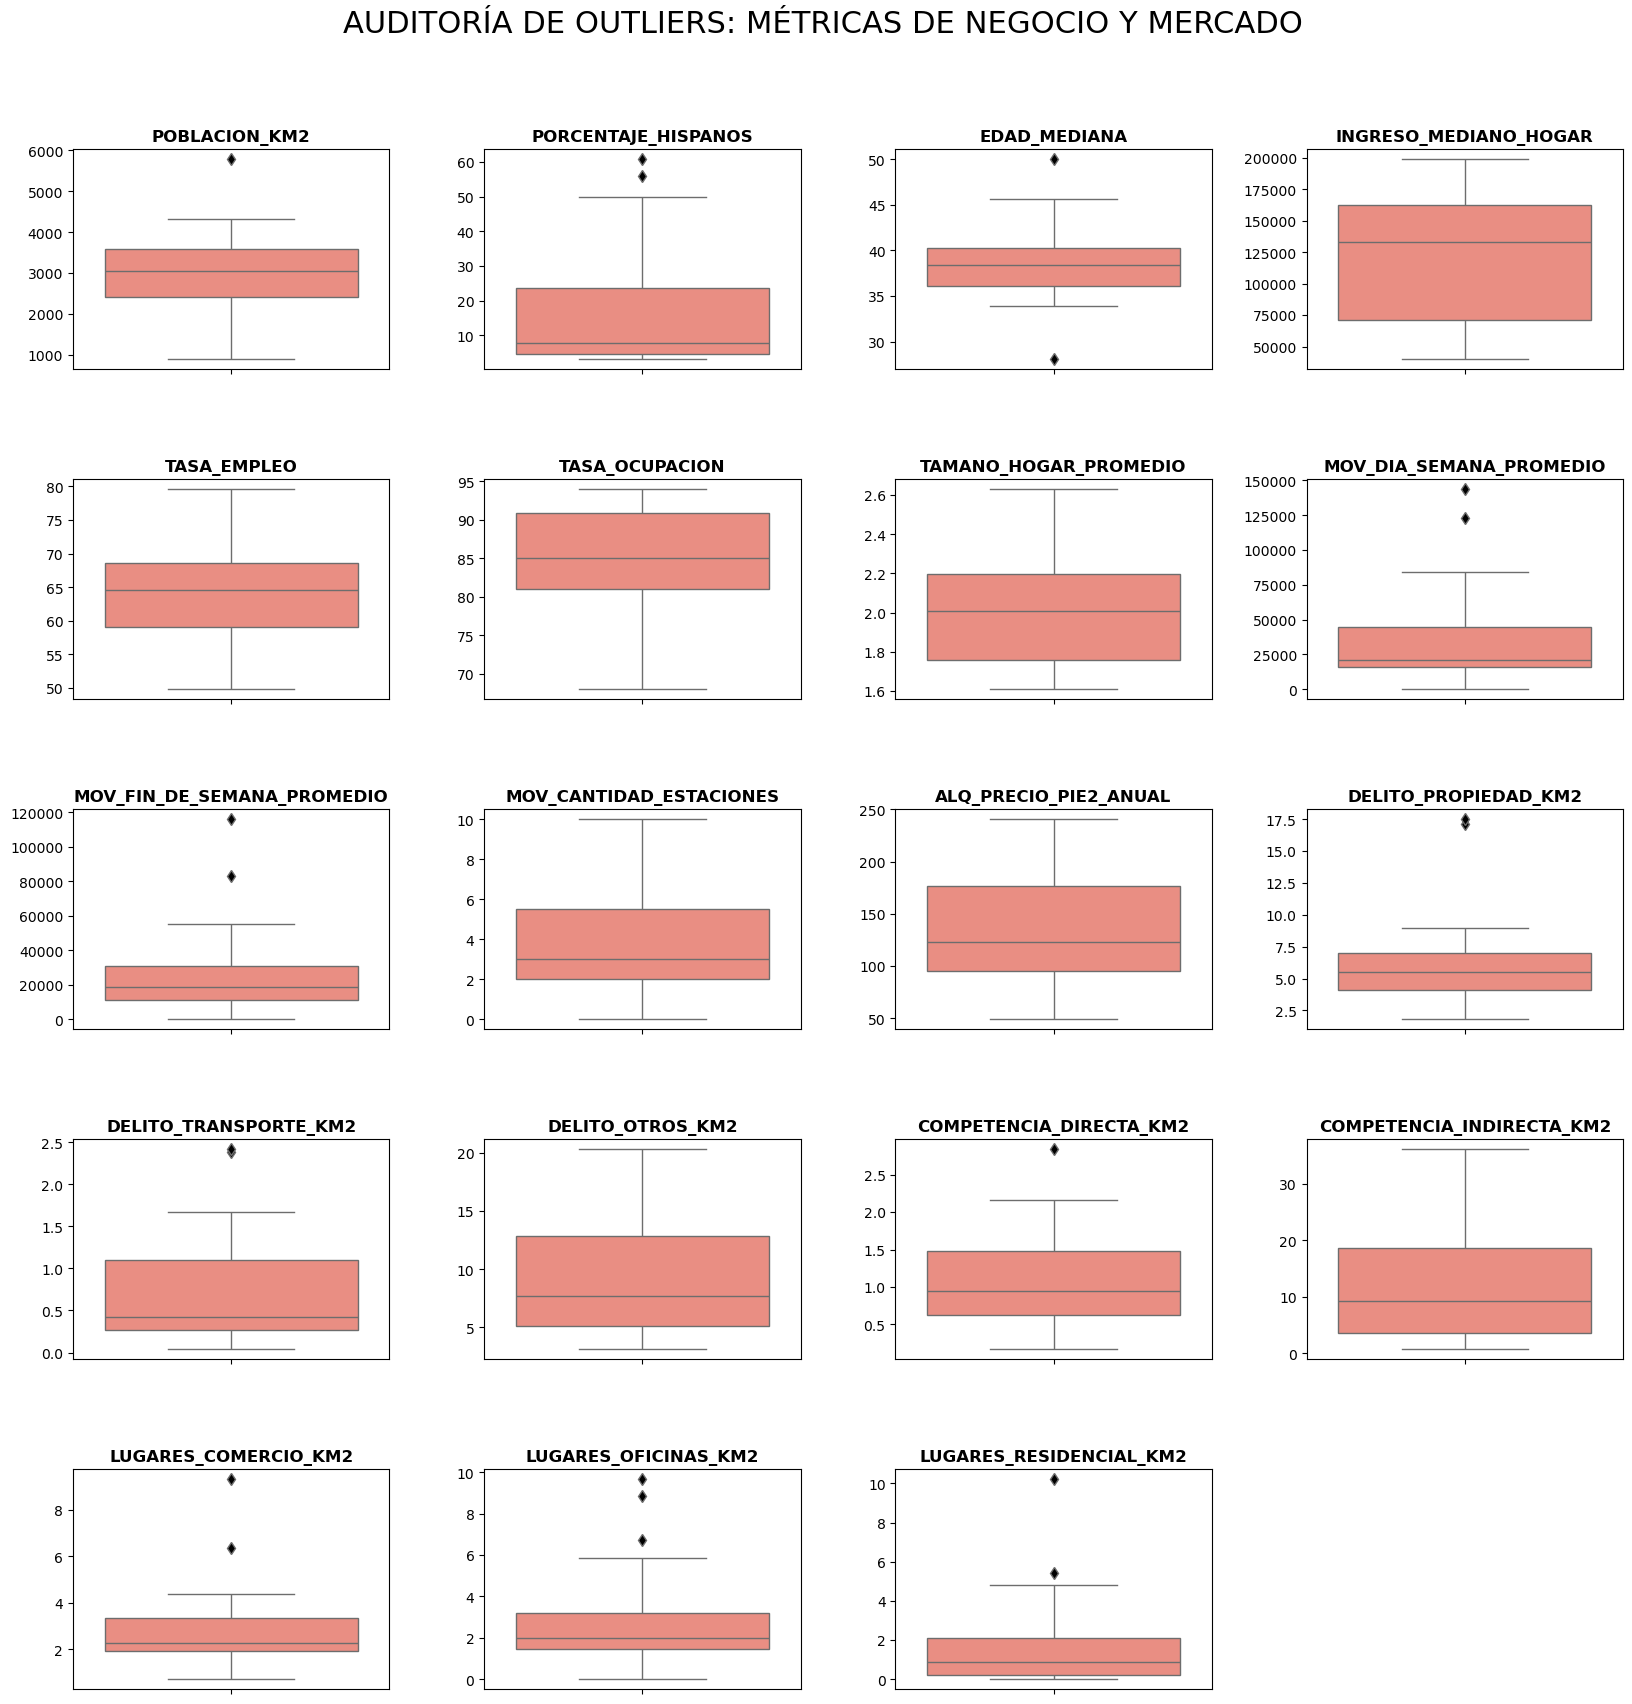

📋 REPORTE DE VALORES ATÍPICOS (Z-Score > 3):
------------------------------------------------------------
📍 Variable: MOV_DIA_SEMANA_PROMEDIO
ID_ZONA          NOMBRE_ZONA  MOV_DIA_SEMANA_PROMEDIO
 MN0502 Midtown-Times Square                 143758.0
------------------------------
📍 Variable: MOV_FIN_DE_SEMANA_PROMEDIO
ID_ZONA          NOMBRE_ZONA  MOV_FIN_DE_SEMANA_PROMEDIO
 MN0502 Midtown-Times Square                    116060.0
------------------------------
📍 Variable: DELITO_PROPIEDAD_KM2
ID_ZONA                         NOMBRE_ZONA  DELITO_PROPIEDAD_KM2
 MN0501 Midtown South-Flatiron-Union Square                 17.14
 MN0502                Midtown-Times Square                 17.51
------------------------------
📍 Variable: LUGARES_COMERCIO_KM2
ID_ZONA          NOMBRE_ZONA  LUGARES_COMERCIO_KM2
 MN0502 Midtown-Times Square                  9.33
------------------------------
📍 Variable: LUGARES_OFICINAS_KM2
ID_ZONA             NOMBRE_ZONA  LUGARES_OFICINAS_KM2
 MN0604 East Midtown

In [44]:
# PASO 3: ANALISIS DE VALORES ATIPICOS (OUTLIERS)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 3.1 Configuración de rutas
directorio = '../../datos/maestro'
archivo_entrada = os.path.join(directorio, 'MASTER_DATASET_MANHATTAN_LIMPIO.csv')

# 3.2 Carga del dataset limpio
df = pd.read_csv(archivo_entrada)

# 3.3 Selección de variables para análisis de outliers
cols_excluir = ['ID_ZONA', 'NOMBRE_ZONA', 'AREA_KM2']
cols_graficar = [col for col in df.columns if col not in cols_excluir]

# 3.4 Configuración del Layout Dinámico
n_cols = 4
n_rows = (len(cols_graficar) + n_cols - 1) // n_cols

plt.figure(figsize=(20, 4 * n_rows))
plt.subplots_adjust(hspace=0.5, wspace=0.3)
plt.suptitle("AUDITORÍA DE OUTLIERS: MÉTRICAS DE NEGOCIO Y MERCADO", fontsize=22, y=0.95)

# 3.5 Generación de Boxplots
for i, col in enumerate(cols_graficar):
    plt.subplot(n_rows, n_cols, i+1)
    # Usamos un color distintivo para diferenciarlo de los pasos anteriores
    sns.boxplot(y=df[col], color='salmon', flierprops={"marker": "d", "markerfacecolor": "black", "markersize": 6})
    plt.title(f"{col}", fontsize=12, fontweight='bold')
    plt.ylabel("")

# 3.6 Guardado de la imagen
grafica_path = os.path.join(directorio, 'OUTLIERS_ANALISIS.png')
plt.savefig(grafica_path)
plt.show()

# 3.7 Reporte detallado de Outliers detectados
print("📋 REPORTE DE VALORES ATÍPICOS (Z-Score > 3):")
print("-" * 60)
for col in cols_graficar:
    # Verificamos que sea numérica antes de calcular
    if pd.api.types.is_numeric_dtype(df[col]):
        mean, std = df[col].mean(), df[col].std()
        outliers = df[df[col] > mean + 3 * std][['ID_ZONA', 'NOMBRE_ZONA', col]]
        if not outliers.empty:
            print(f"📍 Variable: {col}")
            print(outliers.to_string(index=False))
            print("-" * 30)

print(f"✅ PASO 3 COMPLETADO: Gráficos de Outliers guardados en '{grafica_path}'")

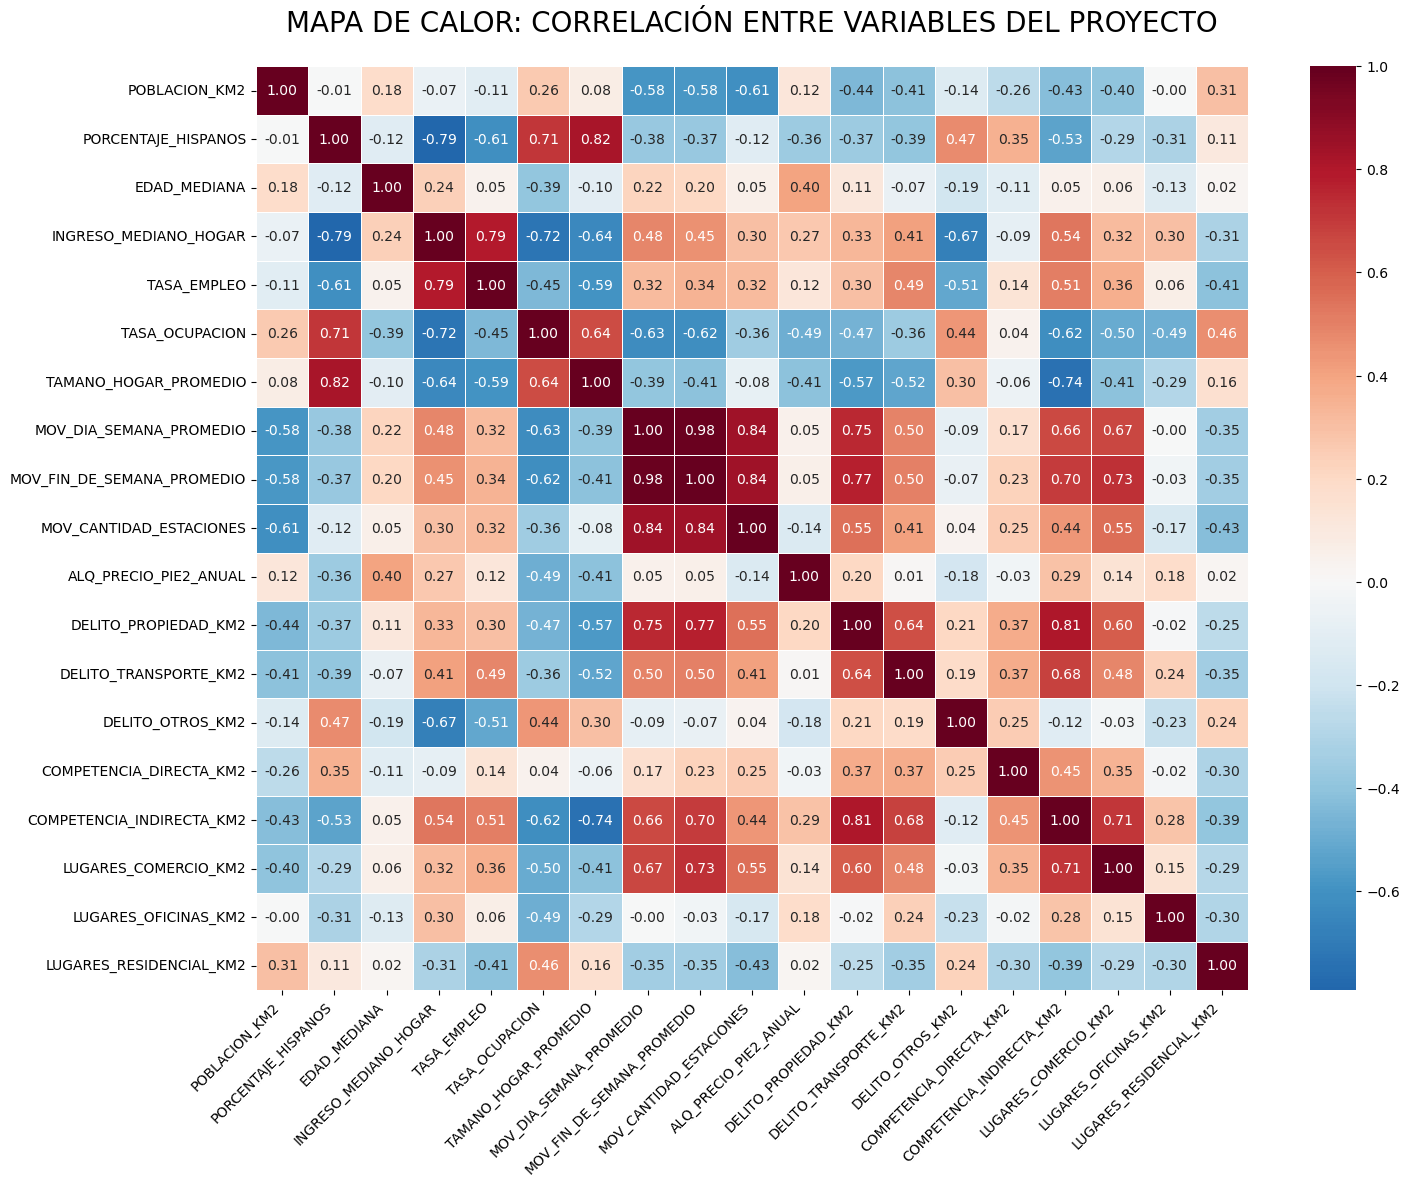

⚠️ DETECCIÓN DE REDUNDANCIAS (Correlación > 0.85):
------------------------------------------------------------
🔗 'MOV_DIA_SEMANA_PROMEDIO' y 'MOV_FIN_DE_SEMANA_PROMEDIO' están muy vinculadas: 0.98
------------------------------------------------------------
✅ PASO 4 COMPLETADO: Análisis de correlación guardado en 'Dataset_Final\MATRIZ_CORRELACION.png'


In [47]:
# PASO 4:ANALISIS DE CORRELACION

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# 4.1 Configuración de rutas
directorio = '../../datos/maestro'
archivo_entrada = os.path.join(directorio, 'MASTER_DATASET_MANHATTAN_LIMPIO.csv')

# 4.2 Carga del dataset
df = pd.read_csv(archivo_entrada)

# 4.3 Selección de variables para análisis de correlacion
cols_excluir = ['ID_ZONA', 'NOMBRE_ZONA', 'AREA_KM2']
df_corr = df.drop(columns=cols_excluir)

# 4.4 Cálculo de la Matriz de Correlación (Pearson)
corr_matrix = df_corr.corr()

# 4.5 Generación del Heatmap
plt.figure(figsize=(16, 12))
# Usamos una paleta divergente (RdBu_r) para ver claro lo positivo y negativo
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt=".2f", 
            cmap='RdBu_r', 
            center=0, 
            linewidths=0.5,
            annot_kws={"size": 10})

plt.title("MAPA DE CALOR: CORRELACIÓN ENTRE VARIABLES DEL PROYECTO", fontsize=20, pad=25)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# 4.6 Guardado del análisis
grafica_corr = os.path.join(directorio, 'MATRIZ_CORRELACION.png')
plt.savefig(grafica_corr, bbox_inches='tight')
plt.show()

# 4.7 Reporte de alta correlación por consola
print("⚠️ DETECCIÓN DE REDUNDANCIAS (Correlación > 0.85):")
print("-" * 60)
# Extraemos solo la parte superior de la matriz para no repetir parejas
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr = [column for column in upper.columns if any(upper[column].abs() > 0.85)]

if not high_corr:
    print("No se detectaron variables con correlación extrema. El dataset es equilibrado.")
else:
    for col in upper.columns:
        pairs = upper[col][upper[col].abs() > 0.85]
        for index, value in pairs.items():
            print(f"🔗 '{index}' y '{col}' están muy vinculadas: {value:.2f}")

print("-" * 60)
print(f"✅ PASO 4 COMPLETADO: Análisis de correlación guardado en '{grafica_corr}'")

In [57]:
#PASO 5: TRATAMIENTO DE VARIABLES CORRELACIONADAS

import pandas as pd
import os

# 5.1 Configuración de rutas
directorio = '../../datos/maestro'
archivo_entrada = os.path.join(directorio, 'MASTER_DATASET_MANHATTAN_LIMPIO.csv')
archivo_unificado = os.path.join(directorio, 'MASTER_DATASET_MANHATTAN_ML.csv')

# 5.2 Carga del dataset
df = pd.read_csv(archivo_entrada)

# 5.3 UUnificacion de variables - Movilidad (Lógica Ponderada)
# Calculamos la MOVILIDAD_PROMEDIO_DIARIA: (5 días de semana + 2 de fin de semana) / 7
if 'MOV_DIA_SEMANA_PROMEDIO' in df.columns and 'MOV_FIN_DE_SEMANA_PROMEDIO' in df.columns:
    # Calculamos el promedio ponderado de los 7 días
    calculo_movilidad = ((df['MOV_DIA_SEMANA_PROMEDIO'] * 5) + 
                         (df['MOV_FIN_DE_SEMANA_PROMEDIO'] * 2)) / 7
    
    # Redondeamos a 0 decimales y convertimos a entero 
    df['MOVILIDAD_PROMEDIO_DIARIA'] = calculo_movilidad.round(0).astype(int)
    
    # Eliminamos las columnas originales redundantes
    df.drop(columns=['MOV_DIA_SEMANA_PROMEDIO', 'MOV_FIN_DE_SEMANA_PROMEDIO'], inplace=True)

print("🔄 TRATAMIENTO DE MOVILIDAD: Resuelto (Fusión Semana/Finde).")

# 5.4 Eliminación de TASA_EMPLEO (Redundancia con Ingreso)
if 'TASA_EMPLEO' in df.columns:
    df.drop(columns=['TASA_EMPLEO'], inplace=True)
    print("🗑️ ELIMINACIÓN DE TASA_EMPLEO: Realizada (Evitamos multicolinealidad con el Ingreso).")

# 5.5 Visualización y Verificación
print(f"📊 Estado Final: {df.shape[0]} zonas y {df.shape[1]} columnas.")
print("-" * 70)
# Mostramos el resultado para confirmar la estructura final antes del Z-Score
display(df.head(31))

# 5.6 Guardado del dataset unificado
df.to_csv(archivo_unificado, index=False)
print(f"📄 Archivo guardado: {archivo_unificado}")


🔄 TRATAMIENTO DE MOVILIDAD: Resuelto (Fusión Semana/Finde).
🗑️ ELIMINACIÓN DE TASA_EMPLEO: Realizada (Evitamos multicolinealidad con el Ingreso).
📊 Estado Final: 31 zonas y 20 columnas.
----------------------------------------------------------------------


,ID_ZONA,NOMBRE_ZONA,AREA_KM2,POBLACION_KM2,PORCENTAJE_HISPANOS,EDAD_MEDIANA,INGRESO_MEDIANO_HOGAR,TASA_OCUPACION,TAMANO_HOGAR_PROMEDIO,MOV_CANTIDAD_ESTACIONES,ALQ_PRECIO_PIE2_ANUAL,DELITO_PROPIEDAD_KM2,DELITO_TRANSPORTE_KM2,DELITO_OTROS_KM2,COMPETENCIA_DIRECTA_KM2,COMPETENCIA_INDIRECTA_KM2,LUGARES_COMERCIO_KM2,LUGARES_OFICINAS_KM2,LUGARES_RESIDENCIAL_KM2,MOVILIDAD_PROMEDIO_DIARIA
0,MN0101,Financial District-Battery Park City,19.2268,2528.14,3.37,34.3,198961.0,83.10,1.99,10.0,91.91,4.06,1.46,3.80,1.25,15.86,6.35,1.92,0.31,71700
1,MN0102,Tribeca-Civic Center,13.5782,1712.82,3.75,36.8,185902.0,81.41,2.20,6.0,122.72,5.67,0.96,8.54,0.81,11.05,2.06,3.09,0.07,52278
2,MN0201,SoHo-Little Italy-Hudson Square,12.9168,1716.14,4.40,39.3,132900.0,82.01,1.78,6.0,190.54,8.98,0.46,6.81,0.93,21.29,3.10,1.16,0.00,48016
3,MN0202,Greenwich Village,10.6005,2973.16,3.18,35.7,174062.0,78.61,1.74,4.0,99.03,7.55,1.51,8.77,1.42,22.83,3.58,8.87,0.09,28664
4,MN0203,West Village,14.4169,2255.55,7.27,39.7,168629.0,80.94,1.68,3.0,220.81,7.01,1.18,5.13,1.25,19.77,2.29,1.04,0.00,18305
5,MN0302,Lower East Side,16.4732,2798.91,26.06,42.2,58841.0,90.54,2.05,3.0,107.90,4.37,0.55,12.81,0.85,13.23,3.10,1.46,4.80,29110
6,MN0303,East Village,18.9848,3603.51,17.44,33.9,76136.0,91.01,1.83,2.0,127.58,7.06,0.21,7.69,1.69,22.49,4.37,2.21,3.90,20463
7,MN0401,Chelsea-Hudson Yards,29.6718,2085.41,9.70,39.2,126272.0,83.90,1.67,6.0,63.64,7.55,0.57,6.34,0.81,11.93,2.33,1.01,0.88,60403
8,MN0402,Hell's Kitchen,18.3823,3004.03,11.87,39.1,105839.0,87.46,1.61,2.0,126.14,7.40,2.39,15.34,1.96,17.41,2.67,1.69,0.49,11889
9,MN0501,Midtown South-Flatiron-Union Square,14.8790,1994.09,5.03,35.2,182280.0,82.85,1.65,9.0,68.50,17.14,2.42,12.84,1.75,33.27,3.63,2.49,0.00,111626


📄 Archivo guardado: Dataset_Final\MASTER_DATASET_MANHATTAN_ML.csv


In [58]:
# PASO 6: ESTANDARIZACION/NORMALIZACION (Z-SCORE)

from sklearn.preprocessing import StandardScaler
import pandas as pd
import os

# 6.1 Configuración de rutas
directorio = '../../datos/maestro'
archivo_unificado = os.path.join(directorio, 'MASTER_DATASET_MANHATTAN_ML.csv')
archivo_final = os.path.join(directorio, 'MASTER_DATASET_MANHATTAN_ZSCORE.csv')

# 6.2 Carga del dataset 
df_unificado = pd.read_csv(archivo_unificado)

# 6.3 Selección de columnas para estandarizar
cols_excluir = ['ID_ZONA', 'NOMBRE_ZONA', 'AREA_KM2']
cols_a_estandarizar = [col for col in df_unificado.columns if col not in cols_excluir]

# 6.4 Aplicación de Z-Score
# El StandardScaler centra los datos en 0 y escala según la desviación estándar
scaler = StandardScaler()
df_zscore = df_unificado.copy()

# Transformación matemática de las métricas de negocio
df_zscore[cols_a_estandarizar] = scaler.fit_transform(df_unificado[cols_a_estandarizar])

# Redondeamos a 3 decimales para balancear precisión y legibilidad en el CSV
df_zscore[cols_a_estandarizar] = df_zscore[cols_a_estandarizar].round(3)

# 6.5 Guardado definitivo del producto final para el modelo de Clustering
df_zscore.to_csv(archivo_final, index=False)

print("-" * 75)
print(f"🚀 PASO 6 FINALIZADO: Dataset estandarizado.")
print(f"📊 Variables procesadas: {len(cols_a_estandarizar)}")
print(f"📂 Archivo Maestro Final: '{archivo_final}'")
print("-" * 75)

display(df_zscore.head(31))

---------------------------------------------------------------------------
🚀 PASO 6 FINALIZADO: Dataset estandarizado.
📊 Variables procesadas: 17
📂 Archivo Maestro Final: 'Dataset_Final\MASTER_DATASET_MANHATTAN_ZSCORE.csv'
---------------------------------------------------------------------------


,ID_ZONA,NOMBRE_ZONA,AREA_KM2,POBLACION_KM2,PORCENTAJE_HISPANOS,EDAD_MEDIANA,INGRESO_MEDIANO_HOGAR,TASA_OCUPACION,TAMANO_HOGAR_PROMEDIO,MOV_CANTIDAD_ESTACIONES,ALQ_PRECIO_PIE2_ANUAL,DELITO_PROPIEDAD_KM2,DELITO_TRANSPORTE_KM2,DELITO_OTROS_KM2,COMPETENCIA_DIRECTA_KM2,COMPETENCIA_INDIRECTA_KM2,LUGARES_COMERCIO_KM2,LUGARES_OFICINAS_KM2,LUGARES_RESIDENCIAL_KM2,MOVILIDAD_PROMEDIO_DIARIA
0,MN0101,Financial District-Battery Park City,19.2268,-0.541,-0.798,-1.077,1.613,-0.240,-0.092,2.458,-0.737,-0.610,1.171,-1.133,0.261,0.458,2.164,-0.381,-0.600,1.296
1,MN0102,Tribeca-Civic Center,13.5782,-1.419,-0.776,-0.466,1.350,-0.493,0.583,0.845,-0.152,-0.134,0.391,-0.138,-0.440,-0.060,-0.478,0.145,-0.710,0.659
2,MN0201,SoHo-Little Italy-Hudson Square,12.9168,-1.415,-0.738,0.145,0.285,-0.403,-0.768,0.845,1.134,0.844,-0.390,-0.501,-0.249,1.042,0.163,-0.722,-0.741,0.519
3,MN0202,Greenwich Village,10.6005,-0.062,-0.809,-0.735,1.113,-0.911,-0.896,0.039,-0.602,0.421,1.249,-0.090,0.531,1.208,0.459,2.741,-0.701,-0.116
4,MN0203,West Village,14.4169,-0.834,-0.568,0.243,1.003,-0.563,-1.089,-0.364,1.708,0.262,0.734,-0.854,0.261,0.879,-0.336,-0.776,-0.741,-0.456
5,MN0302,Lower East Side,16.4732,-0.249,0.539,0.854,-1.203,0.872,0.101,-0.364,-0.433,-0.518,-0.249,0.759,-0.377,0.175,0.163,-0.587,1.441,-0.102
6,MN0303,East Village,18.9848,0.617,0.031,-1.175,-0.855,0.942,-0.607,-0.767,-0.060,0.277,-0.780,-0.316,0.961,1.171,0.945,-0.250,1.032,-0.385
7,MN0401,Chelsea-Hudson Yards,29.6718,-1.018,-0.425,0.121,0.152,-0.121,-1.121,0.845,-1.273,0.421,-0.218,-0.600,-0.440,0.035,-0.311,-0.789,-0.341,0.925
8,MN0402,Hell's Kitchen,18.3823,-0.028,-0.297,0.096,-0.258,0.412,-1.314,-0.767,-0.088,0.377,2.623,1.290,1.392,0.625,-0.102,-0.484,-0.519,-0.667
9,MN0501,Midtown South-Flatiron-Union Square,14.8790,-1.116,-0.700,-0.857,1.278,-0.278,-1.186,2.055,-1.180,3.254,2.670,0.765,1.057,2.331,0.489,-0.125,-0.741,2.606
